In [1]:
import os,shutil, sys
import polars as pl
from pydantic import BaseModel, ValidationError
from pydantic.errors import PydanticUndefinedAnnotation
from datetime import datetime
import logging
import requests

try:
    tripdata = requests.get("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet")
except requests.exceptions.RequestException as err:
    logging.warning(err)

base_path = os.path.expanduser("~/Desktop/my_streamlit_appcopy/data/raw")

# create folder
os.makedirs(base_path, exist_ok=True)

with open(base_path + "/yellow_tripdata_2024-01.parquet", "wb") as f:
    f.write(tripdata.content)


class TripTable(BaseModel):
    tpep_pickup_datetime: datetime
    tpep_dropoff_datetime: datetime
    passenger_count: int
    trip_distance: float
    fare_amount: float
    tip_amount: float
    total_amount: float
    payment_type: int

try:
    TripTable.model_rebuild()
except PydanticUndefinedAnnotation as exc_info:
    assert exc_info.code == 'undefined-annotation'

TripTable_df = pl.read_parquet(tripdata.content).select(["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID", "passenger_count", "trip_distance", "fare_amount", "tip_amount", "total_amount", "payment_type"]) #load entire dataset for transformations

print("TaxiZone Entries",TripTable_df.height)

try:
    TripTable.model_validate(TripTable_df.row(0,named=True),strict = True) #strict_mode in pydantic will raise and error log it for missing rows or incorrect datatypes. For parquet, It's standard that all rows contain same datatype and the first row of the dataframe should
except ValidationError as exc:
    #triptable.model_validate(Tra) If needed, data type coercion can be handled by Pydantic(lax_mode) during validation or by DuckDB/Polars(fastest option) during DataFrame processing, although this wasn’t asked.
    #logging.warning(exc)
    print(exc)


print(TripTable_df)
print("Validated")

TaxiZone Entries 2964624
shape: (2_964_624, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ tpep_pick ┆ tpep_drop ┆ PULocatio ┆ DOLocatio ┆ … ┆ fare_amou ┆ tip_amoun ┆ total_amo ┆ payment_ │
│ up_dateti ┆ off_datet ┆ nID       ┆ nID       ┆   ┆ nt        ┆ t         ┆ unt       ┆ type     │
│ me        ┆ ime       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ ---       ┆ ---       ┆ i32       ┆ i32       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ i64      │
│ datetime[ ┆ datetime[ ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ ns]       ┆ ns]       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2024-01-0 ┆ 2024-01-0 ┆ 186       ┆ 79        ┆ … ┆ 17.7      ┆ 0.0       ┆ 22.7      ┆ 2        │
│ 1         ┆ 1         ┆           ┆      

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
.master('local[*]') \
.appName('Assignment3') \
.config('spark.sql.adaptive.enabled', 'true') \
.config('spark.driver.memory', '4g') \
.getOrCreate()
# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 20:59:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1
App name: Assignment3
Master: local[*]
Default parallelism: 8


In [3]:
df = spark.read.parquet(base_path + "/yellow_tripdata_2024-01.parquet")
# Inspect the schema (column names and data types)
df.printSchema()
# Basic statistics
print(f'Number of rows: {df.count():,}')
print(f'Number of columns: {len(df.columns)}')
print(f'Number of partitions: {df.rdd.getNumPartitions()}')

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

Number of rows: 2,964,624
Number of columns: 19
Number of partitions: 8


In [4]:
from pyspark.sql import functions as F

trips = df.select(
F.col('tpep_pickup_datetime').alias('pickup_time'),
F.col('tpep_dropoff_datetime').alias('dropoff_time'),
'passenger_count',
'trip_distance',
'fare_amount',
'tip_amount',
'total_amount',
'payment_type',
'PULocationID',
'DOLocationID'
)

#pickup/dropoff times, locations, fare,distance
trips_clean = trips.na.drop(subset=['pickup_time','dropoff_time','fare_amount','tip_amount','trip_distance','PULocationID','DOLocationID'])

print(trips.count() - trips_clean.count())

# Filter out invalid data
trips_clean = trips.filter(
(F.col('trip_distance') > 0) &
(F.col('fare_amount') > 0) &
(F.col('fare_amount') < 500) &
(F.col('total_amount') > 0) &
(F.col('passenger_count') > 0)
)

trips_enriched = trips_clean.withColumns({
'trip_duration_min': (F.unix_timestamp('dropoff_time')- F.unix_timestamp('pickup_time')) / 60,
'trip_speed_mph': F.when(F.col('trip_duration_min') != 0, F.col('trip_distance')/(F.col('trip_duration_min')/60)).otherwise(None),
'pickup_hour': F.hour('pickup_time'),
'pickup_day': F.dayofweek('pickup_time'),
'tip_percentage': F.when(F.col('fare_amount') != 0,(F.col('tip_amount') / F.col('fare_amount') * 100)).otherwise(None),
})

trips_enriched = trips_enriched.na.drop(subset=['trip_speed_mph','tip_percentage'])
#trips_enriched.show(5)
print(trips_clean.count())
print(trips_enriched.count())

trips_enriched.show()

0
2723771
2723724
+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+------------------+------------------+-----------+----------+------------------+
|        pickup_time|       dropoff_time|passenger_count|trip_distance|fare_amount|tip_amount|total_amount|payment_type|PULocationID|DOLocationID| trip_duration_min|    trip_speed_mph|pickup_hour|pickup_day|    tip_percentage|
+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+------------------+------------------+-----------+----------+------------------+
|2024-01-01 00:57:55|2024-01-01 01:17:43|              1|         1.72|       17.7|       0.0|        22.7|           2|         186|          79|              19.8| 5.212121212121212|          0|         2|               0.0|
|2024-01-01 00:03:00|2024-01-01 00:09:36|              1|          1.8|   

In [5]:
trips_enriched.createOrReplaceTempView('trips')
# Query 1: Top 10 busiest pickup locations
busiest_locations = spark.sql('''
SELECT PULocationID,
COUNT(*) as num_trips,
ROUND(AVG(fare_amount), 2) as avg_fare,
ROUND(AVG(trip_distance), 2) as avg_distance
FROM trips
GROUP BY PULocationID
ORDER BY num_trips DESC
LIMIT 10
''')
print('Top 10 Busiest Pickup Locations:')
busiest_locations.show()

Top 10 Busiest Pickup Locations:


[Stage 18:====================================>                     (5 + 3) / 8]

+------------+---------+--------+------------+
|PULocationID|num_trips|avg_fare|avg_distance|
+------------+---------+--------+------------+
|         132|   136935|   62.79|       15.93|
|         237|   135459|    12.3|         1.7|
|         161|   134966|   15.45|        2.32|
|         236|   128098|   12.73|        1.84|
|         162|   101248|   15.02|        2.25|
|         186|    99455|   16.06|        2.29|
|         230|    98960|   17.83|        2.96|
|         142|    97633|    13.5|         2.1|
|         138|    86560|   42.34|        9.71|
|         239|    81339|   13.35|        2.07|
+------------+---------+--------+------------+



In [6]:
highest_average_trip = spark.sql('''
SELECT pickup_hour,
    AVG(trip_speed_mph) AS Trip_Speed, 
    AVG(trip_distance) AS Average_Trip_Speed, 
    AVG(trip_duration_min) AS Average_Trip_Duration
FROM trips
GROUP BY pickup_hour
ORDER BY Trip_Speed DESC
LIMIT 1
''').show()

[Stage 21:====================================>                     (5 + 3) / 8]

+-----------+------------------+------------------+---------------------+
|pickup_hour|        Trip_Speed|Average_Trip_Speed|Average_Trip_Duration|
+-----------+------------------+------------------+---------------------+
|          5|20.428208459755286| 6.206320066547223|   17.103972570599776|
+-----------+------------------+------------------+---------------------+



In [7]:
top_5_pick_up_hours_by_total_revenue = spark.sql('''
SELECT *
FROM (
    SELECT
        pickup_day,
        PULocationID,
        SUM(total_amount) AS total_revenue,
        RANK() OVER (
            PARTITION BY pickup_day
            ORDER BY SUM(total_amount) DESC
        ) AS revenue_rank
    FROM trips
    GROUP BY pickup_day,
             pickup_day,
             PULocationID
) AS ranked
WHERE revenue_rank <= 5
ORDER BY pickup_day, revenue_rank
''')

top_5_pick_up_hours_by_total_revenue.show(35)
trips_enriched.printSchema()

[Stage 24:====================================>                     (5 + 3) / 8]

+----------+------------+------------------+------------+
|pickup_day|PULocationID|     total_revenue|revenue_rank|
+----------+------------+------------------+------------+
|         1|         132|1548117.6899999843|           1|
|         1|         138| 753292.9400000012|           2|
|         1|         230|334986.95000000036|           3|
|         1|         186|257176.40999999997|           4|
|         1|         161|241690.17000000068|           5|
|         2|         132|2032380.7199999376|           1|
|         2|         138|1008672.1700000037|           2|
|         2|         161| 446340.9100000032|           3|
|         2|         237| 357318.4100000018|           4|
|         2|         236| 353877.3400000013|           5|
|         3|         132|1775342.4599999576|           1|
|         3|         138| 925148.6300000021|           2|
|         3|         161| 592216.8300000015|           3|
|         3|         237| 474431.9100000035|           4|
|         3|  

In [8]:
trips_enriched.createOrReplaceTempView('trips')

cumalative_trip_data = spark.sql('''
SELECT pickup_day, pickup_hour, cumulative_pct
FROM (
    SELECT
        pickup_day,
        pickup_hour,
        ROUND(
            SUM(COUNT(*)) OVER (PARTITION BY pickup_day ORDER BY pickup_hour)
            / SUM(COUNT(*)) OVER (PARTITION BY pickup_day)
            * 100, 2
        ) AS cumulative_pct
    FROM trips
    GROUP BY pickup_day, pickup_hour
) AS cumulative
WHERE cumulative_pct >= 50
ORDER BY pickup_day, pickup_hour DESC
''').show(200) 
#review this query

[Stage 30:====================================>                     (5 + 3) / 8]

+----------+-----------+--------------+
|pickup_day|pickup_hour|cumulative_pct|
+----------+-----------+--------------+
|         1|         23|         100.0|
|         1|         22|         97.39|
|         1|         21|         93.86|
|         1|         20|         89.51|
|         1|         19|         84.92|
|         1|         18|         79.88|
|         1|         17|         73.77|
|         1|         16|         67.31|
|         1|         15|         60.66|
|         1|         14|         54.08|
|         2|         23|         100.0|
|         2|         22|         97.53|
|         2|         21|          94.1|
|         2|         20|         89.52|
|         2|         19|         84.34|
|         2|         18|         78.38|
|         2|         17|         71.26|
|         2|         16|         64.21|
|         2|         15|         57.52|
|         2|         14|         50.79|
|         3|         23|         100.0|
|         3|         22|          97.5|


In [9]:
trip_categories = spark.sql('''
SELECT
    CASE
        WHEN trip_distance < 1 THEN 'Very Short (< 1 mi)'
        WHEN trip_distance < 3 THEN 'Short (1-3 mi)'
        WHEN trip_distance < 10 THEN 'Medium (3-10 mi)'
        ELSE 'Long (10+ mi)'
    END as distance_category,
COUNT(*) as num_trips,
ROUND(AVG(fare_amount), 2) as avg_fare,
ROUND(AVG(tip_percentage), 2) as avg_tip_pct
FROM trips
GROUP BY distance_category
ORDER BY avg_tip_pct DESC
''')
print('Trip Categories by Distance:')
trip_categories.show()

Trip Categories by Distance:


[Stage 36:====================================>                     (5 + 3) / 8]

+-------------------+---------+--------+-----------+
|  distance_category|num_trips|avg_fare|avg_tip_pct|
+-------------------+---------+--------+-----------+
|Very Short (< 1 mi)|   642819|    7.68|      25.44|
|     Short (1-3 mi)|  1362081|   12.87|      21.72|
|   Medium (3-10 mi)|   500394|   27.17|      17.91|
|      Long (10+ mi)|   218430|   64.75|      15.81|
+-------------------+---------+--------+-----------+



In [10]:
import urllib.request, os
os.makedirs("documents", exist_ok=True)
# Download the original RAG research paper

urllib.request.urlretrieve(
"https://arxiv.org/pdf/2005.11401v4",
"documents/rag_paper.pdf"
)

# 1. NYC TLC 2024 Annual Report
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2024.pdf",
    "documents/01_tlc_annual_report_2024.pdf"
)
 
# 2. Feb 2025 For-Hire Vehicle License Review
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/license-pause-report-2025-02.pdf",
    "documents/02_fhv_license_review_feb2025.pdf"
)
 
# 3. TLC 2020 Factbook
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/2020-tlc-factbook.pdf",
    "documents/03_tlc_factbook_2020.pdf"
)
 
# --- Driver Pay & Labor Economics ---
 
# 4. Parrott & Reich (2018) — App-Based Driver Earnings Standard
urllib.request.urlretrieve(
    "https://static1.squarespace.com/static/5953059b1b10e384f55aad08/t/685eb1a7aa7067164f3af6e6/1751036332078/Parrott-Reich%2BNYC%2BApp%2BDrivers%2BTLC%2BJul%2B2018jul1.pdf",
    "documents/04_parrott_reich_driver_earnings_2018.pdf"
)
 
# 5. Parrott (Dec 2024) — Revised HV-FHV Driver Expense Model
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/driver_expense_report.pdf",
    "documents/05_driver_expense_model_2024.pdf"
)
 
# --- Fleet Electrification ---
 
# 6. TLC Electrification in Motion (Sep 2024)
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/electrification_in_motion_report_2024.pdf",
    "documents/06_electrification_in_motion_2024.pdf"
)
 
# --- Congestion Pricing & Traffic Policy ---
 
# 7. CBD Tolling Program Environmental Assessment — Executive Summary
urllib.request.urlretrieve(
    "https://www.mta.info/document/110756",
    "documents/07_cbd_tolling_ea_exec_summary.pdf"
)
 
# 8. IBO Fare Play — Yellow Taxi Congestion Pricing Exemption
urllib.request.urlretrieve(
    "https://ibo.nyc.ny.us/iboreports/fare-play-considerations-for-exempting-yellow-taxis-from-a-congestion-pricing-surcharge-february-2024.pdf",
    "documents/08_fare_play_congestion_pricing_ibo.pdf"
)
 
# --- Academic Research ---
 
# 9. Cook et al. (NBER 2025) — Short-Run Effects of Congestion Pricing in NYC
urllib.request.urlretrieve(
    "https://www.nber.org/system/files/working_papers/w33584/w33584.pdf",
    "documents/09_nber_congestion_pricing_effects_2025.pdf"
)
 
# 10. Predicting Taxi Pickups in Cities (ML + TLC data)
urllib.request.urlretrieve(
    "https://cpemis.eng.cmu.ac.th/~santi/purba2017/paper/PURBA-2017_paper_8.pdf",
    "documents/10_predicting_taxi_pickups.pdf"
)

print("Downloaded files:")
print(os.listdir("documents"))

Downloaded files:
['05_driver_expense_model_2024.pdf', '01_tlc_annual_report_2024.pdf', '.localized', 'rag_paper.pdf', '08_fare_play_congestion_pricing_ibo.pdf', '07_cbd_tolling_ea_exec_summary.pdf', '06_electrification_in_motion_2024.pdf', '10_predicting_taxi_pickups.pdf', '09_nber_congestion_pricing_effects_2025.pdf', '04_parrott_reich_driver_earnings_2018.pdf', '03_tlc_factbook_2020.pdf', '02_fhv_license_review_feb2025.pdf', '.ipynb_checkpoints']


In [11]:
from pypdf import PdfReader
from langchain_community.document_loaders import PyPDFDirectoryLoader

loader = PyPDFDirectoryLoader("documents/")
raw_documents = loader.load()

print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"First document metadata: {raw_documents[0].metadata}")
print(f"First 200 chars: {raw_documents[0].page_content[:200]}")

/Users/danielmangal/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 343 pages from all PDFs
First document metadata: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-01-30T11:07:12-08:00', 'moddate': '2025-01-30T11:07:16-08:00', 'trapped': '/False', 'source': 'documents/05_driver_expense_model_2024.pdf', 'total_pages': 45, 'page': 0, 'page_label': '1'}
First 200 chars: James A. Parrott
December 2024
Revised Expense Model for  
the NYC Taxi and Limousine 
Commission’s High-Volume For-Hire 
Vehicle Minimum Pay Standard
Report for the New York City Taxi and 
Limousine 


In [12]:
for doc in raw_documents:
    if len(doc.page_content.strip()) < 50:
        print(f"Short/empty page: {doc.metadata}")
# Check character count distribution
lengths = [len(d.page_content) for d in raw_documents]
print(f"Avg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")

Short/empty page: {'producer': 'Adobe PDF Library 23.1.175', 'creator': 'Acrobat PDFMaker 23 for Word', 'creationdate': '2023-04-26T14:02:59-07:00', 'author': '', 'comments': '', 'company': '', 'contenttypeid': '0x010100067883C9B342FF40AC733DFD5AB13A3D', 'grammarlydocumentid': '1a6630de61b1eb2546d3ffcd4b07f5b5072022b4261008c54e4eb57e2881fc43', 'manager': '', 'mediaserviceimagetags': '', 'moddate': '2023-04-26T17:25:42-07:00', 'nccl_app': 'PDF', 'nccl_standard': 'PDF/UA;', 'nccl_status': 'Passed', 'sourcemodified': 'D:20230426210005', 'subject': '', 'title': 'Executive Summary', '_dlc_dociditemguid': 'f247050f-6f58-4b51-817e-3607608a247d', 'bjclsuserrvm': '[]', 'bjdocumentsecuritylabel': 'No Marking', 'bjlabelhistoryid': '{D64D0FAD-8548-4FD6-887F-970DBA6C085D}', 'bjsaver': 'YwPnkSm5157I3EVy1k2XW7GY9BhaOZty', 'docindexref': 'ed567521-23be-4069-976a-b705fbb8007d', 'source': 'documents/07_cbd_tolling_ea_exec_summary.pdf', 'total_pages': 54, 'page': 1, 'page_label': '2'}
Short/empty page: {

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, # Target characters per chunk
    chunk_overlap=200, # Overlap between consecutive chunks
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 343 pages into 1218 chunks



=== Chunk 0 ===
Length: 210 chars
Source: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-01-30T11:07:12-08:00', 'moddate': '2025-01-30T11:07:16-08:00', 'trapped': '/False', 'source': 'documents/05_driver_expense_model_2024.pdf', 'total_pages': 45, 'page': 0, 'page_label': '1'}
Preview: James A. Parrott
December 2024
Revised Expense Model for  
the NYC Taxi and Limousine 
Commission’s High-Volume For-Hire 
Vehicle Minimum Pay Standard
Report for the New York City Taxi and 
Limousine ...

=== Chunk 1 ===
Length: 948 chars
Source: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-01-30T11:07:12-08:00', 'moddate': '2025-01-30T11:07:16-08:00', 'trapped': '/False', 'source': 'documents/05_driver_expense_model_2024.pdf', 'total_pages': 45, 'page': 1, 'page_label': '2'}
Preview: Revised TLC HV-FHV Minimum Pay Standard Expense Model
Acknowledgments 
This report was prepared by J

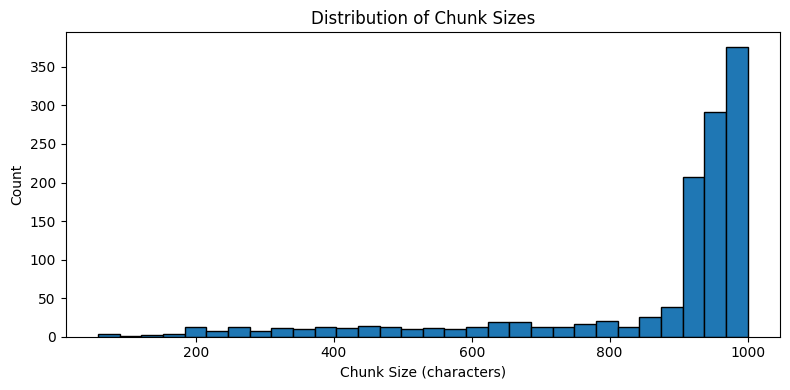

In [14]:
for i, chunk in enumerate(chunks[:3]):
    print(f"\n=== Chunk {i} ===")
    print(f"Length: {len(chunk.page_content)} chars")
    print(f"Source: {chunk.metadata}")
    print(f"Preview: {chunk.page_content[:200]}...")
# Visualize chunk size distribution
import matplotlib.pyplot as plt
sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

In [15]:
# Confirm that adjacent chunks share overlapping text
chunk_a = chunks[0].page_content
chunk_b = chunks[1].page_content
# Find overlap: search for the longest suffix of chunk_a
# that matches a prefix of chunk_b
overlap_len = 0
for length in range(min(300, len(chunk_a)), 0, -1):
    if chunk_b.startswith(chunk_a[-length:]):
        overlap_len = length
        break
print(f"Overlap length: {overlap_len} chars")

if overlap_len > 0:
    print(f"Overlap text: {chunk_a[-overlap_len:][:100]}...")
else:
    print("No overlap found (chunks may be from different documents)")

Overlap length: 0 chars
No overlap found (chunks may be from different documents)


In [16]:
import chromadb

# ChromaDB uses all-MiniLM-L6-v2 (ONNX) by default
client = chromadb.Client()

collection = client.create_collection(name="documents")

# Example: adding documents with metadata (source filename, page number)
collection.add(
    documents=[
        "Machine learning is a subset of artificial intelligence.",
        "Deep learning uses neural networks with many layers.",
        "Natural language processing deals with text and speech.",
    ],
    metadatas=[
        {"source_filename": "intro_to_ml.pdf", "page_number": 1},
        {"source_filename": "intro_to_ml.pdf", "page_number": 5},
        {"source_filename": "nlp_basics.pdf", "page_number": 2},
    ],
    ids=["doc1", "doc2", "doc3"],
)

# Query the collection
results = collection.query(
    query_texts=["What is deep learning?"],
    n_results=2,
)

print("Documents:", results["documents"])
print("Metadatas:", results["metadatas"])
print("Distances:", results["distances"])

Documents: [['Deep learning uses neural networks with many layers.', 'Machine learning is a subset of artificial intelligence.']]
Metadatas: [[{'source_filename': 'intro_to_ml.pdf', 'page_number': 5}, {'source_filename': 'intro_to_ml.pdf', 'page_number': 1}]]
Distances: [[0.6054633259773254, 0.9194358587265015]]


In [17]:
import numpy as np
import chromadb.utils.embedding_functions as embedding_functions

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Use ChromaDB's default embedding function (all-MiniLM-L6-v2 via ONNX)
embedding_model = embedding_functions.DefaultEmbeddingFunction()

e1 = embedding_model(["How does a neural network learn?"])[0]
e2 = embedding_model(["What is backpropagation in deep learning?"])[0]
e3 = embedding_model(["What is the capital of France?"])[0]

print(f"Similar topics: {cosine_similarity(e1, e2):.4f}")
print(f"Different topics: {cosine_similarity(e1, e3):.4f}")

Similar topics: 0.5958
Different topics: 0.0925


In [18]:
from langchain.embeddings.base import Embeddings
import chromadb.utils.embedding_functions as embedding_functions

class ChromaEmbeddings(Embeddings):
    def __init__(self):
        self.ef = embedding_functions.DefaultEmbeddingFunction()

    def embed_documents(self, texts):
        return self.ef(texts)

    def embed_query(self, text):
        return self.ef([text])[0]

embedding_model = ChromaEmbeddings()

In [19]:
from langchain_community.vectorstores import Chroma
# Create the vector store from chunks
vectorstore = Chroma.from_documents(
documents=chunks,
embedding=embedding_model,
persist_directory="./chroma_db",
collection_name="lab6_docs"
)
print(f"Indexed {len(chunks)} chunks in ChromaDB")

Indexed 1218 chunks in ChromaDB


In [20]:
# Three chunk sizes to test
chunk_sizes = [500, 1000, 2000]
sample_queries = [
    "What is machine learning?",
    "How does backpropagation work?",
    "What are the applications of AI?",
]

for size in chunk_sizes:
    print(f"\n{'='*60}")
    print(f"CHUNK SIZE: {size}")
    print(f"{'='*60}")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=int(size * 0.2),  # 20% overlap
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    chunks = splitter.split_documents(raw_documents)
    print(f"Total chunks: {len(chunks)}")

    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        collection_name=f"chunks_{size}",
    )

    for query in sample_queries:
        print(f"\nQuery: '{query}'")
        results = vectorstore.similarity_search_with_score(query, k=3)
        for i, (doc, score) in enumerate(results):
            page = doc.metadata.get("page", "?")
            print(f"  Result {i+1} (score: {score:.4f}, page: {page}): {doc.page_content[:100]}...")


CHUNK SIZE: 500
Total chunks: 2401

Query: 'What is machine learning?'
  Result 1 (score: 1.3374, page: 1): human taxi drivers can intuitively predict demand by 
location and time, based on their prior experi...
  Result 2 (score: 1.3648, page: 13): Automated Knowledge Base Construction, 2020. URL https://openreview.net/forum?
id=025X0zPfn.
[49] Al...
  Result 3 (score: 1.3737, page: 37): model with many parameters to calibrate towards specific vehicle models. However, FASTSim
requires s...

Query: 'How does backpropagation work?'
  Result 1 (score: 1.2909, page: 14): Ł ukasz Kaiser, and Illia Polosukhin. Attention is all you need. In I. Guyon, U. V . Luxburg,
S. Ben...
  Result 2 (score: 1.3664, page: 11): pages 1601–1611, Vancouver, Canada, July 2017. Association for Computational Linguistics.
doi: 10.18...
  Result 3 (score: 1.4368, page: 8): architecture, by learning a retrieval module to augment pre-trained, generative language models.
Lea...

Query: 'What are the applications of

Interpretation of scores: 

In [25]:
from openai import OpenAI

LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = "sk-syn-3c754a9ef2ef62c72844c98101274c0b8b245196c67e1f4b"

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
)
print("Client configured successfully.")
print(f"Base URL: {client.base_url}")

# List available models
models = client.models.list()
for m in models.data:
    print(f"- {m.id}")

# Test a completion
response = client.chat.completions.create(
    model="llama3.3-70b-instruct",
    messages=[
        {"role": "user", "content": "What is Big Data Analytics in one sentence?"}
    ],
    max_tokens=100
)
print(response.choices[0].message.content)
print(f"\nTokens used - Prompt: {response.usage.prompt_tokens}, "
      f"Completion: {response.usage.completion_tokens}, "
      f"Total: {response.usage.total_tokens}")

import tiktoken

prompt_text = "What is Big Data Analytics in one sentence?"
encoding = tiktoken.get_encoding("cl100k_base")
tokens = encoding.encode(prompt_text)

print(f"Prompt: {prompt_text!r}")
print(f"Token count (tiktoken): {len(tokens)}")
print(f"Token IDs: {tokens}")
print(f"Decoded tokens: {[encoding.decode([t]) for t in tokens]}")
print()
print(f"API-reported prompt tokens: {response.usage.prompt_tokens}")
print("Note: The API count is higher because the server adds chat-template")
print("tokens (e.g. role markers) that wrap your raw prompt.")
print()
print("Tip: Monitor your remaining credits at the /usage page on Synapse.")


Client configured successfully.
Base URL: https://synapse.sergiomathurin.com/v1/
- llama3.3-70b-instruct
- llama3-8b-instruct
- openai-gpt-oss-120b
- openai-gpt-oss-20b
- mistral-nemo-instruct-2407
- alibaba-qwen3-32b
- deepseek-r1-distill-llama-70b
Big Data Analytics refers to the process of examining large and complex data sets to uncover hidden patterns, correlations, and insights, using advanced statistical and computational methods, to inform business decisions and drive strategic outcomes.

Tokens used - Prompt: 44, Completion: 41, Total: 85


In [28]:
import json

def extract_entities(text):
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system",
             "content": "You are an entity extraction system. Extract entities "
                 "from the given text and return ONLY valid JSON with no additional text. "
                 "Use this exact schema: "
                 '{"people": [{"name": "...", "role": "..."}], '
                 '"organizations": [{"name": "...", "type": "..."}], '
                 '"locations": [{"name": "...", "context": "..."}], '
                 '"dates": [{"date": "...", "event": "..."}]}'
                 " If a field has no entities, use an empty list."},
            {"role": "user", "content": f"Extract entities from: {text}"}
        ],
        max_tokens=500,
        temperature=0
    )
    raw = response.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    try:
        return json.loads(raw)
    except json.JSONDecodeError as e:
        print(f"Warning: Failed to parse JSON: {e}")
        print(f"Raw response: {raw[:200]}")
        return {"error": str(e), "raw_response": raw}


sample = ("Dr. Sarah Chen, lead researcher at MIT's Computer Science department, "
    "published a groundbreaking paper on neural networks on March 15, 2024. "
    "The research was funded by Google DeepMind and conducted in collaboration "
    "with Stanford University in Palo Alto, California.")

result = extract_entities(sample)
print(json.dumps(result, indent=2))


reviews = [
    "Amazing phone! Battery lasts forever and the camera is stunning.",
    "Worst purchase ever. Broke after 2 days. Customer support was unhelpful.",
    "Decent laptop for the price. Keyboard is good but screen could be better.",
]


def analyze_review(review):
    resp = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system",
             "content": "Analyze the product review and return ONLY valid JSON: "
                 '{"sentiment": "positive"|"negative"|"mixed", '
                 '"confidence": 0.0 to 1.0, '
                 '"aspects": [{"feature": "...", "opinion": "positive"|"negative"}], '
                 '"summary": "one sentence summary"}'},
            {"role": "user", "content": review}
        ],
        max_tokens=200,
        temperature=0
    )
    raw = resp.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(raw)


for review in reviews:
    analysis = analyze_review(review)
    print(f"Review: {review[:50]}...")
    print(f"Result: {json.dumps(analysis, indent=2)}\n")

{
  "people": [
    {
      "name": "Sarah Chen",
      "role": "lead researcher"
    }
  ],
  "organizations": [
    {
      "name": "MIT",
      "type": "university"
    },
    {
      "name": "Google DeepMind",
      "type": "research organization"
    },
    {
      "name": "Stanford University",
      "type": "university"
    }
  ],
  "locations": [
    {
      "name": "Palo Alto",
      "context": "city"
    },
    {
      "name": "California",
      "context": "state"
    }
  ],
  "dates": [
    {
      "date": "March 15, 2024",
      "event": "paper publication"
    }
  ]
}
Review: Amazing phone! Battery lasts forever and the camer...
Result: {
  "sentiment": "positive",
  "confidence": 0.9,
  "aspects": [
    {
      "feature": "battery",
      "opinion": "positive"
    },
    {
      "feature": "camera",
      "opinion": "positive"
    }
  ],
  "summary": "The phone has a long-lasting battery and a stunning camera."
}

Review: Worst purchase ever. Broke after 2 days. Customer